# Classification using Decision Tree, Random Forest, Naive bayes, KNN, Logistic Regression, SVM

# Airline Passenger Satisfaction Classification

This dataset contains an airline passenger satisfaction survey. What factors are highly correlated to a satisfied (or dissatisfied) passenger? Can you predict passenger satisfaction?



In [82]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder


# 1- Gathering data

In [83]:
df = pd.read_csv("train.csv")
df_test = pd.read_csv('test.csv')

In [84]:
df.shape

(103904, 25)

In [85]:
df_test.shape

(25976, 25)

In [86]:
df.columns

Index(['Unnamed: 0', 'id', 'Gender', 'Customer Type', 'Age', 'Type of Travel',
       'Class', 'Flight Distance', 'Inflight wifi service',
       'Departure/Arrival time convenient', 'Ease of Online booking',
       'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
       'Inflight entertainment', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Inflight service',
       'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes',
       'satisfaction'],
      dtype='object')

In [87]:
df.head()

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


Columns of the Dataset

The columns present in the dataset are as follows:

    Gender: Gender of the passengers (Female, Male)

    Customer Type: The customer type (Loyal customer, disloyal customer)

    Age: The actual age of the passengers

    Type of Travel: Purpose of the flight of the passengers (Personal Travel, Business Travel)

    Class: Travel class in the plane of the passengers (Business, Eco, Eco Plus)

    Flight distance: The flight distance of this journey

    Inflight wifi service: Satisfaction level of the inflight wifi service (0:Not Applicable;1-5)

    Departure/Arrival time convenient: Satisfaction level of Departure/Arrival time convenient

    Ease of Online booking: Satisfaction level of online booking

    Gate location: Satisfaction level of Gate location

    Food and drink: Satisfaction level of Food and drink

    Online boarding: Satisfaction level of online boarding

    Seat comfort: Satisfaction level of Seat comfort

    Inflight entertainment: Satisfaction level of inflight entertainment

    On-board service: Satisfaction level of On-board service

    Leg room service: Satisfaction level of Leg room service

    Baggage handling: Satisfaction level of baggage handling

    Check-in service: Satisfaction level of Check-in service

    Inflight service: Satisfaction level of inflight service

    Cleanliness: Satisfaction level of Cleanliness

    Departure Delay in Minutes: Minutes delayed when departure

    Arrival Delay in Minutes: Minutes delayed when Arrival

    Satisfaction: Airline satisfaction level(Satisfaction, neutral or dissatisfaction)

# 2- Data Exploration

In [88]:
# Describe data
df.describe()

,Unnamed: 0,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103594.000000
mean,51951.500000,64924.210502,39.379706,1189.448375,2.729683,3.060296,2.756901,2.976883,3.202129,3.250375,3.439396,3.358158,3.382363,3.351055,3.631833,3.304290,3.640428,3.286351,14.815618,15.178678
std,29994.645522,37463.812252,15.114964,997.147281,1.327829,1.525075,1.398929,1.277621,1.329533,1.349509,1.319088,1.332991,1.288354,1.315605,1.180903,1.265396,1.175663,1.312273,38.230901,38.698682
min,0.000000,1.000000,7.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,25975.750000,32533.750000,27.000000,414.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000
50%,51951.500000,64856.500000,40.000000,843.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000,0.000000,0.000000
75%,77927.250000,97368.250000,51.000000,1743.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,5.000000,4.000000,12.000000,13.000000
max,103903.000000,129880.000000,85.000000,4983.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1592.000000,1584.000000


In [89]:
# Check NaN values
ser_nan_ratios = df.isna().sum()
print(ser_nan_ratios)

Unnamed: 0                             0
id                                     0
Gender                                 0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Inflight wifi service                  0
Departure/Arrival time convenient      0
Ease of Online booking                 0
Gate location                          0
Food and drink                         0
Online boarding                        0
Seat comfort                           0
Inflight entertainment                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Inflight service                       0
Cleanliness                            0
Departure Delay in Minutes             0
Arrival Delay in Minutes             310
satisfaction    

In [90]:
ser_nan_ratios = df_test.isna().sum()
print(ser_nan_ratios)

Unnamed: 0                            0
id                                    0
Gender                                0
Customer Type                         0
Age                                   0
Type of Travel                        0
Class                                 0
Flight Distance                       0
Inflight wifi service                 0
Departure/Arrival time convenient     0
Ease of Online booking                0
Gate location                         0
Food and drink                        0
Online boarding                       0
Seat comfort                          0
Inflight entertainment                0
On-board service                      0
Leg room service                      0
Baggage handling                      0
Checkin service                       0
Inflight service                      0
Cleanliness                           0
Departure Delay in Minutes            0
Arrival Delay in Minutes             83
satisfaction                          0


In [91]:
ser_count = df['satisfaction'].value_counts()
labels = ser_count.index.tolist()  # الترتيب الصحيح حسب النسب

In [92]:
list_target_ratio =[ count/df.shape[0] for count in ser_count ]
print(list_target_ratio)

[0.5666673082845703, 0.43333269171542965]


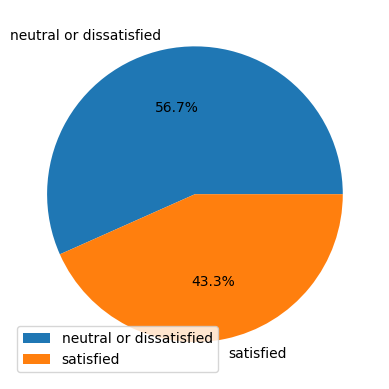

In [93]:
plt.pie(list_target_ratio, labels=labels,autopct='%1.1f%%')
plt.legend()
plt.show()



In [94]:
df

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103899,103899,94171,Female,disloyal Customer,23,Business travel,Eco,192,2,1,...,2,3,1,4,2,3,2,3,0.0,neutral or dissatisfied
103900,103900,73097,Male,Loyal Customer,49,Business travel,Business,2347,4,4,...,5,5,5,5,5,5,4,0,0.0,satisfied
103901,103901,68825,Male,disloyal Customer,30,Business travel,Business,1995,1,1,...,4,3,2,4,5,5,4,7,14.0,neutral or dissatisfied
103902,103902,54173,Female,disloyal Customer,22,Business travel,Eco,1000,1,1,...,1,4,5,1,5,4,1,0,0.0,neutral or dissatisfied


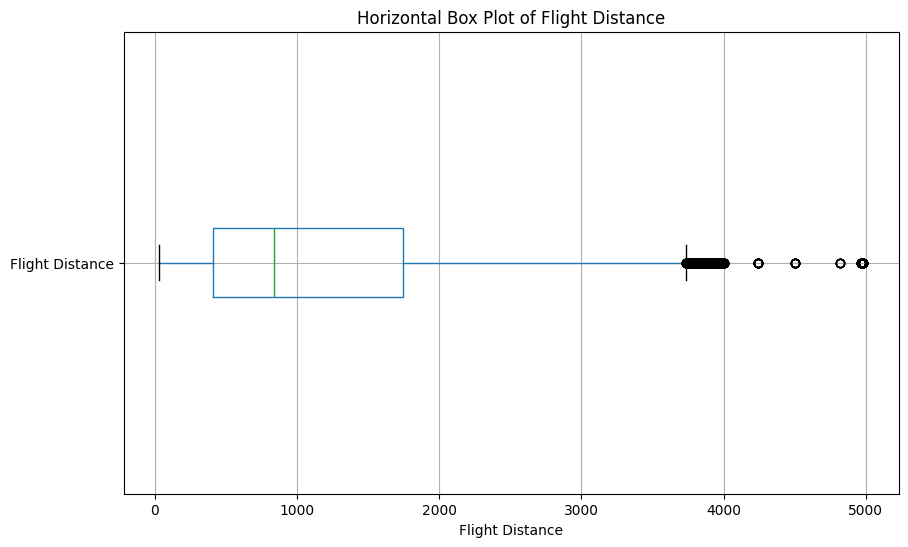

In [95]:
plt.figure(figsize=(10, 6))  # Adjust figure size as needed
df.boxplot(column='Flight Distance', vert=False)  # Create a horizontal box plot
plt.title('Horizontal Box Plot of Flight Distance')
plt.xlabel('Flight Distance')
plt.show()

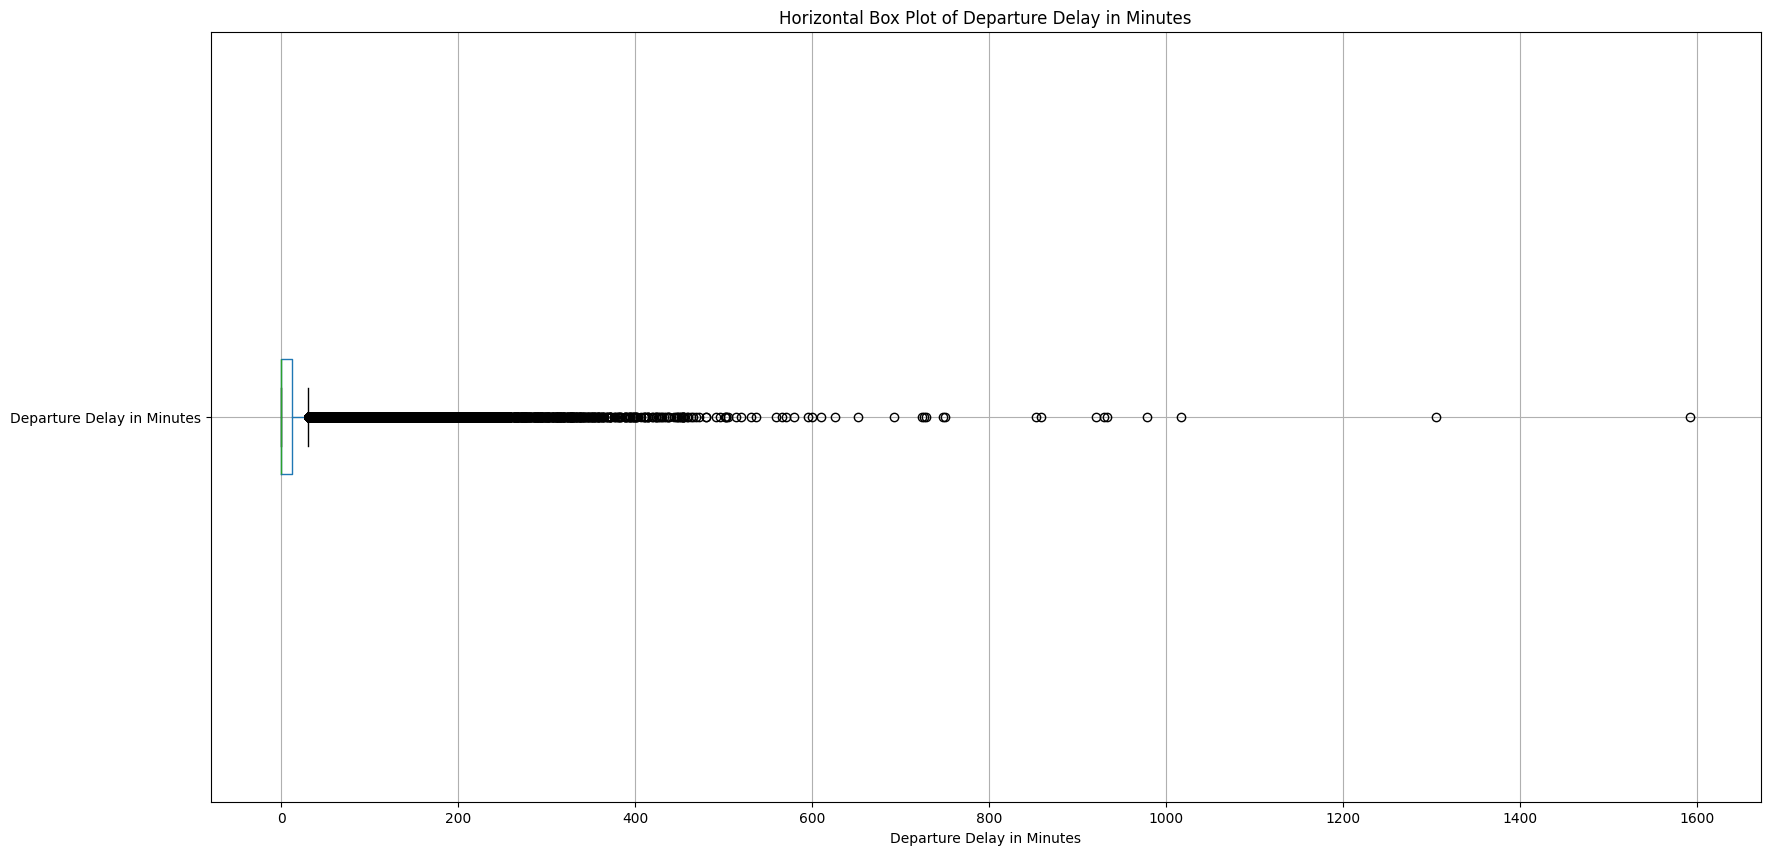

In [96]:
plt.figure(figsize=(20, 10))  # Adjust figure size as needed
df.boxplot(column='Departure Delay in Minutes', vert=False)  # Create a horizontal box plot
plt.title('Horizontal Box Plot of Departure Delay in Minutes')
plt.xlabel('Departure Delay in Minutes')
plt.show()

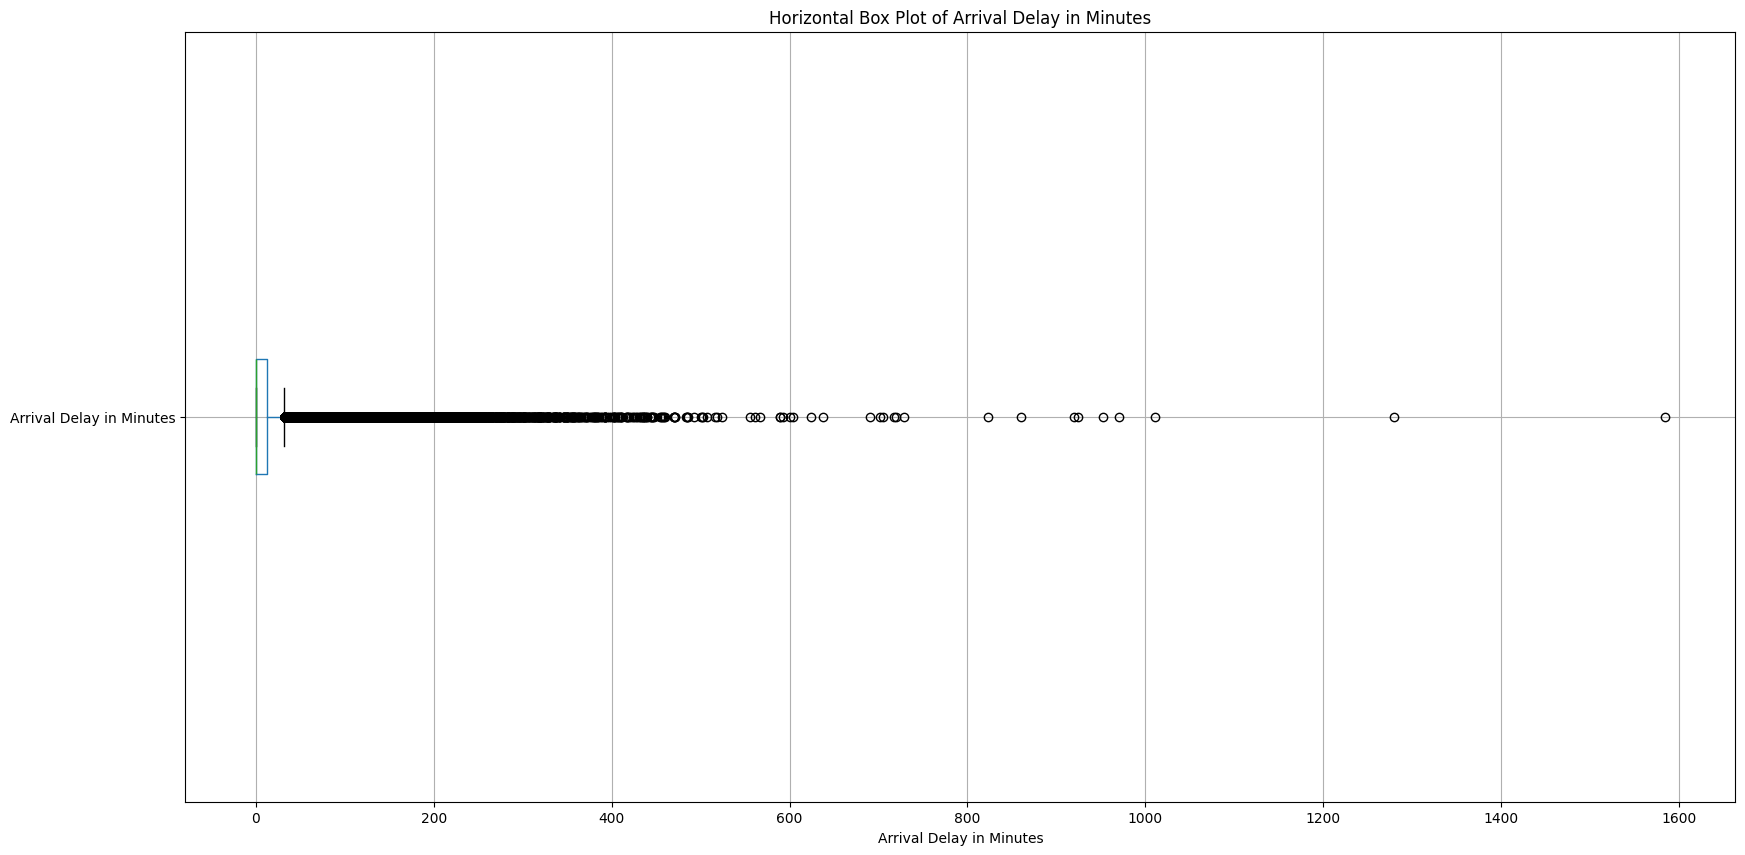

In [97]:
plt.figure(figsize=(20, 10))  # Adjust figure size as needed
df.boxplot(column='Arrival Delay in Minutes', vert=False)  # Create a horizontal box plot
plt.title('Horizontal Box Plot of Arrival Delay in Minutes')
plt.xlabel('Arrival Delay in Minutes')
plt.show()

#3- Data preparation

In [98]:
df_copy = df.copy()
df_copy_test = df_test.copy()

In [99]:
df_copy.columns

Index(['Unnamed: 0', 'id', 'Gender', 'Customer Type', 'Age', 'Type of Travel',
       'Class', 'Flight Distance', 'Inflight wifi service',
       'Departure/Arrival time convenient', 'Ease of Online booking',
       'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
       'Inflight entertainment', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Inflight service',
       'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes',
       'satisfaction'],
      dtype='object')

In [100]:
df_test.columns

Index(['Unnamed: 0', 'id', 'Gender', 'Customer Type', 'Age', 'Type of Travel',
       'Class', 'Flight Distance', 'Inflight wifi service',
       'Departure/Arrival time convenient', 'Ease of Online booking',
       'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
       'Inflight entertainment', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Inflight service',
       'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes',
       'satisfaction'],
      dtype='object')

**Drop Unnamed: 0 , and id**

In [101]:
df_copy.drop(['Unnamed: 0', 'id'], axis=1, inplace=True)
print(df_copy.columns)

Index(['Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class',
       'Flight Distance', 'Inflight wifi service',
       'Departure/Arrival time convenient', 'Ease of Online booking',
       'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
       'Inflight entertainment', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Inflight service',
       'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes',
       'satisfaction'],
      dtype='object')


In [102]:
df_copy_test.drop(['Unnamed: 0','id'],axis = 1, inplace=True)
print(df_copy_test.columns)

Index(['Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class',
       'Flight Distance', 'Inflight wifi service',
       'Departure/Arrival time convenient', 'Ease of Online booking',
       'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
       'Inflight entertainment', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Inflight service',
       'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes',
       'satisfaction'],
      dtype='object')


In [103]:
df_copy

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,1,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,3,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103899,Female,disloyal Customer,23,Business travel,Eco,192,2,1,2,3,...,2,3,1,4,2,3,2,3,0.0,neutral or dissatisfied
103900,Male,Loyal Customer,49,Business travel,Business,2347,4,4,4,4,...,5,5,5,5,5,5,4,0,0.0,satisfied
103901,Male,disloyal Customer,30,Business travel,Business,1995,1,1,1,3,...,4,3,2,4,5,5,4,7,14.0,neutral or dissatisfied
103902,Female,disloyal Customer,22,Business travel,Eco,1000,1,1,1,5,...,1,4,5,1,5,4,1,0,0.0,neutral or dissatisfied


fill the nan values on the train and test data

In [104]:
df_copy["Arrival Delay in Minutes"].fillna(value=df_copy["Arrival Delay in Minutes"].mean(), inplace=True)

<ipython-input-104-8af5eeaa05aa>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_copy["Arrival Delay in Minutes"].fillna(value=df_copy["Arrival Delay in Minutes"].mean(), inplace=True)


In [105]:
df_copy_test["Arrival Delay in Minutes"].fillna(value=df_copy_test["Arrival Delay in Minutes"].mean(), inplace=True)

<ipython-input-105-635e98272d97>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_copy_test["Arrival Delay in Minutes"].fillna(value=df_copy_test["Arrival Delay in Minutes"].mean(), inplace=True)


In [106]:
ser_nan_ratios = df_copy.isna().sum()
print(ser_nan_ratios)

Gender                               0
Customer Type                        0
Age                                  0
Type of Travel                       0
Class                                0
Flight Distance                      0
Inflight wifi service                0
Departure/Arrival time convenient    0
Ease of Online booking               0
Gate location                        0
Food and drink                       0
Online boarding                      0
Seat comfort                         0
Inflight entertainment               0
On-board service                     0
Leg room service                     0
Baggage handling                     0
Checkin service                      0
Inflight service                     0
Cleanliness                          0
Departure Delay in Minutes           0
Arrival Delay in Minutes             0
satisfaction                         0
dtype: int64


In [107]:
ser_nan_ratios = df_copy_test.isna().sum()
print(ser_nan_ratios)

Gender                               0
Customer Type                        0
Age                                  0
Type of Travel                       0
Class                                0
Flight Distance                      0
Inflight wifi service                0
Departure/Arrival time convenient    0
Ease of Online booking               0
Gate location                        0
Food and drink                       0
Online boarding                      0
Seat comfort                         0
Inflight entertainment               0
On-board service                     0
Leg room service                     0
Baggage handling                     0
Checkin service                      0
Inflight service                     0
Cleanliness                          0
Departure Delay in Minutes           0
Arrival Delay in Minutes             0
satisfaction                         0
dtype: int64


Fill the outliar on the 'Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes' columns

In [108]:
columns_to_check = ['Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']

for col in columns_to_check:
    Q1 = df_copy[col].quantile(0.25)
    Q3 = df_copy[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_copy[col] = df_copy[col].clip(lower=lower_bound, upper=upper_bound)
df_copy

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,Male,Loyal Customer,13,Personal Travel,Eco Plus,460.0,3,4,3,1,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,Male,disloyal Customer,25,Business travel,Business,235.0,3,2,3,3,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,Female,Loyal Customer,26,Business travel,Business,1142.0,2,2,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,Female,Loyal Customer,25,Business travel,Business,562.0,2,5,5,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,Male,Loyal Customer,61,Business travel,Business,214.0,3,3,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103899,Female,disloyal Customer,23,Business travel,Eco,192.0,2,1,2,3,...,2,3,1,4,2,3,2,3,0.0,neutral or dissatisfied
103900,Male,Loyal Customer,49,Business travel,Business,2347.0,4,4,4,4,...,5,5,5,5,5,5,4,0,0.0,satisfied
103901,Male,disloyal Customer,30,Business travel,Business,1995.0,1,1,1,3,...,4,3,2,4,5,5,4,7,14.0,neutral or dissatisfied
103902,Female,disloyal Customer,22,Business travel,Eco,1000.0,1,1,1,5,...,1,4,5,1,5,4,1,0,0.0,neutral or dissatisfied


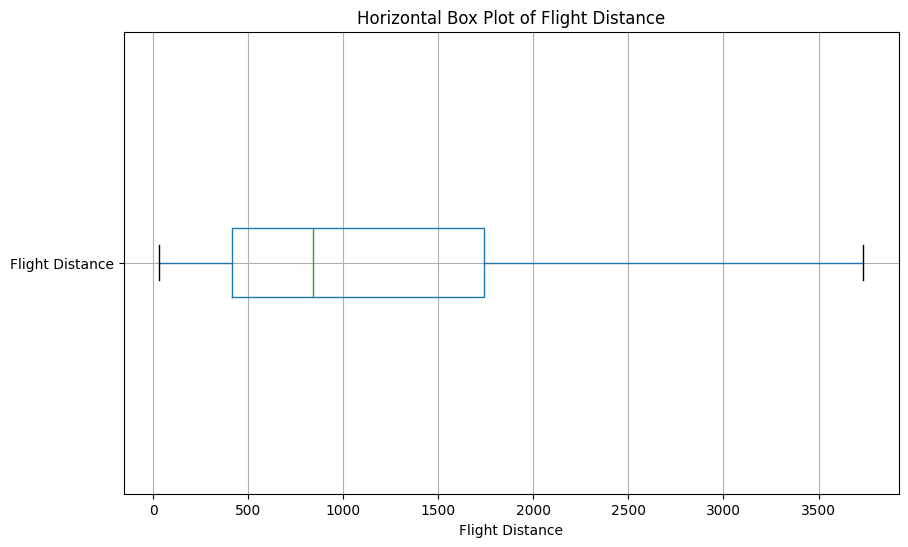

In [109]:
plt.figure(figsize=(10, 6))  # Adjust figure size as needed
df_copy.boxplot(column='Flight Distance', vert=False)  # Create a horizontal box plot
plt.title('Horizontal Box Plot of Flight Distance')
plt.xlabel('Flight Distance')
plt.show()

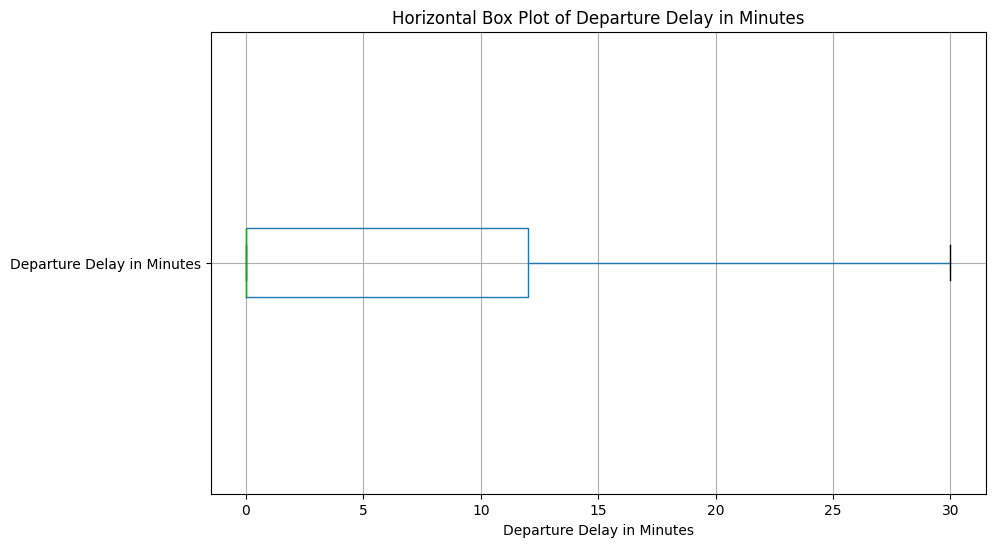

In [110]:
plt.figure(figsize=(10, 6))  # Adjust figure size as needed
df_copy.boxplot(column='Departure Delay in Minutes', vert=False)  # Create a horizontal box plot
plt.title('Horizontal Box Plot of Departure Delay in Minutes')
plt.xlabel('Departure Delay in Minutes')
plt.show()

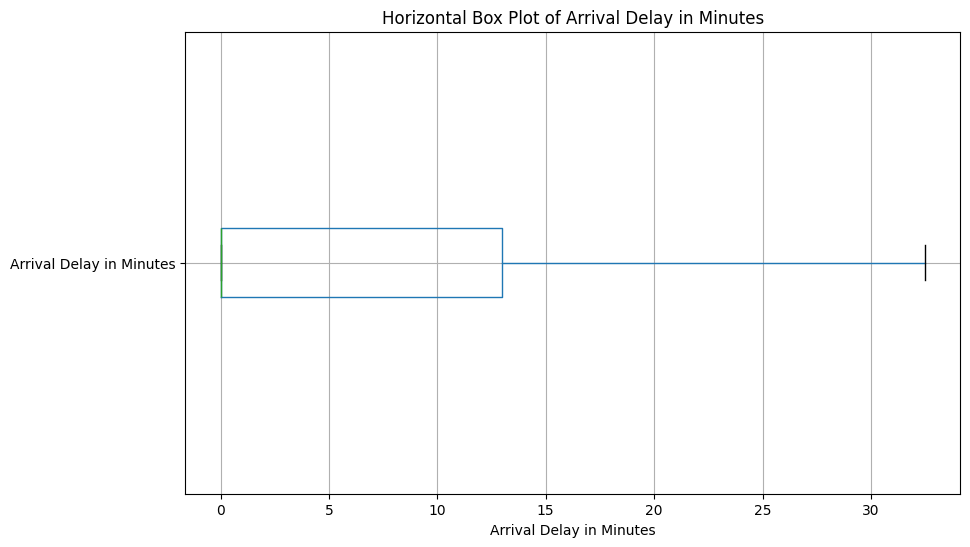

In [111]:
plt.figure(figsize=(10, 6))  # Adjust figure size as needed
df_copy.boxplot(column='Arrival Delay in Minutes', vert=False)  # Create a horizontal box plot
plt.title('Horizontal Box Plot of Arrival Delay in Minutes')
plt.xlabel('Arrival Delay in Minutes')
plt.show()

In [112]:
df_copy.describe()

,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000
mean,39.379706,1186.133927,2.729683,3.060296,2.756901,2.976883,3.202129,3.250375,3.439396,3.358158,3.382363,3.351055,3.631833,3.304290,3.640428,3.286351,7.396299,7.954779
std,15.114964,988.126724,1.327829,1.525075,1.398929,1.277621,1.329533,1.349509,1.319088,1.332991,1.288354,1.315605,1.180903,1.265396,1.175663,1.312273,11.223866,11.964269
min,7.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,27.000000,414.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000
50%,40.000000,843.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000,0.000000,0.000000
75%,51.000000,1743.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,5.000000,4.000000,12.000000,13.000000
max,85.000000,3736.500000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,30.000000,32.500000


In [113]:
df_copy.head()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,Male,Loyal Customer,13,Personal Travel,Eco Plus,460.0,3,4,3,1,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,Male,disloyal Customer,25,Business travel,Business,235.0,3,2,3,3,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,Female,Loyal Customer,26,Business travel,Business,1142.0,2,2,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,Female,Loyal Customer,25,Business travel,Business,562.0,2,5,5,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,Male,Loyal Customer,61,Business travel,Business,214.0,3,3,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [114]:
df_copy["satisfaction"].value_counts()

,count
satisfaction,
neutral or dissatisfied,58879
satisfied,45025


In [115]:

#X = df_copy.drop('satisfaction', axis=1)
#y = df_copy['satisfaction']

# X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.25,random_state=42)

target_column = 'satisfaction'

X_train = df_copy.drop(columns=[target_column])
y_train = df_copy[target_column]


X_test = df_copy_test.drop(columns=[target_column])
y_test = df_copy_test[target_column]


print(f"train data shape {X_train.shape}")
print(f"test data shape {X_test.shape}")

train data shape (103904, 22)
test data shape (25976, 22)


In [116]:
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

X_train['Gender'] = le.fit_transform(X_train['Gender'])
X_test['Gender'] = le.transform(X_test['Gender'])

X_train['Customer Type'] = le.fit_transform(X_train['Customer Type'])
X_test['Customer Type'] = le.transform(X_test['Customer Type'])

X_train['Type of Travel'] = le.fit_transform(X_train['Type of Travel'])
X_test['Type of Travel'] = le.transform(X_test['Type of Travel'])

X_train['Class'] = le.fit_transform(X_train['Class'])
X_test['Class'] = le.transform(X_test['Class'])




Due to some amount of class imbalance,I will oversample the minority class (1) using SMOTE.


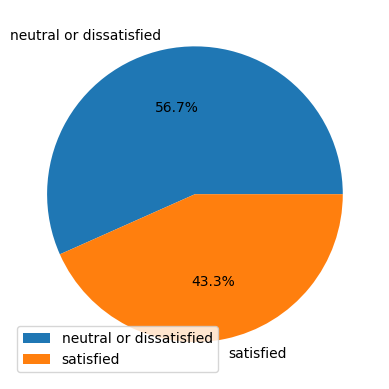

In [117]:
ser_count = df['satisfaction'].value_counts()
labels = ser_count.index.tolist()

list_target_ratio =[ count/df.shape[0] for count in ser_count ]

plt.pie(list_target_ratio, labels=labels,autopct='%1.1f%%')
plt.legend()
plt.show()



Balancing data

In [118]:
# over_sampling = SMOTE()
# X_train, y_train = over_sampling.fit_resample(X_train, y_train)

# y_series = pd.Series(y_train)
# print(y_series.value_counts())

#4- Build Models

In [119]:
decisionTreemodel = DecisionTreeClassifier()
randomForestModel = RandomForestClassifier()
svmModel = SVC(kernel='rbf')
knnModel = KNeighborsClassifier(n_neighbors=7)
naiveBayesModel = GaussianNB()

#5- Traing Models (Modeling)

In [120]:
decisionTreemodel.fit(X_train, y_train)
randomForestModel.fit(X_train, y_train)
svmModel.fit(X_train, y_train)
knnModel.fit(X_train, y_train)
naiveBayesModel.fit(X_train, y_train)

GaussianNB()

#6- Predict

In [121]:
# Decision Tree
decisionTreePrediction = decisionTreemodel.predict(X_test)

# Random Forest Prediction
randomForestPrediction = randomForestModel.predict(X_test)

# Support Vector Machine
svmPrediction = svmModel.predict(X_test)

# K-NN
knnPrediction = knnModel.predict(X_test)

# Naive Bayes
naiveBayesPrediction = naiveBayesModel.predict(X_test)

In [122]:
decisionTreePrediction

array([1, 1, 0, ..., 0, 1, 0])

#7- Evaluation

Evaluate models using confusion martix

In [123]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import ConfusionMatrixDisplay

def Evaluate_classification_model(actual_values, predicted_values):
    return {
        "confusion_matrix": confusion_matrix(actual_values, predicted_values),
        "accuracy": accuracy_score(actual_values, predicted_values),
        "precision": precision_score(actual_values, predicted_values, average='weighted'),
        "recall": recall_score(actual_values, predicted_values, average='weighted'),
        "F1": f1_score(actual_values, predicted_values, average='weighted')
    }


def visualize_confusion_matrix(confusion_matrix, labels):
    disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix,
                                  display_labels=labels)
    disp.plot(cmap=plt.cm.Blues)
    plt.title("Confusion Matrix")
    plt.show()

In [124]:
dict_predictions = {
    "DecisionTree": decisionTreePrediction,
    "RandomForest": randomForestPrediction,
    "KNN": knnPrediction,
    "NaiveBayes": naiveBayesPrediction,
    "SVM": svmPrediction
}

==================== DecisionTree ====================



 confusion_matrix    [[13847, 726], [658, 10745]]
accuracy                                 0.94672
precision                               0.946767
recall                                   0.94672
F1                                      0.946737
dtype: object 



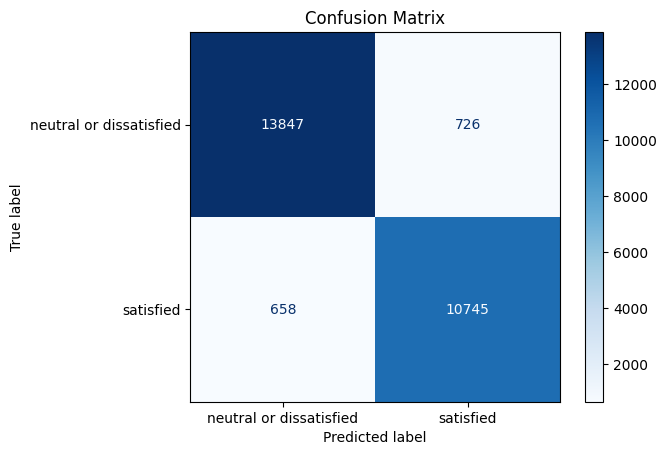

==================== RandomForest ====================



 confusion_matrix    [[14261, 312], [656, 10747]]
accuracy                                0.962735
precision                               0.962944
recall                                  0.962735
F1                                      0.962667
dtype: object 



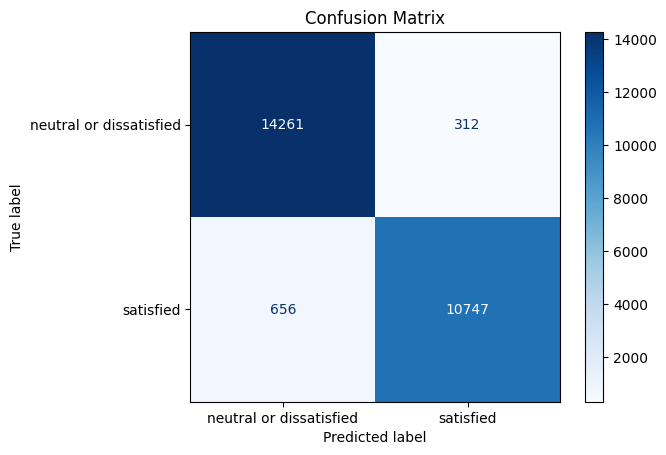

==================== KNN ====================



 confusion_matrix    [[12058, 2515], [3746, 7657]]
accuracy                                  0.75897
precision                                0.758486
recall                                    0.75897
F1                                       0.756977
dtype: object 



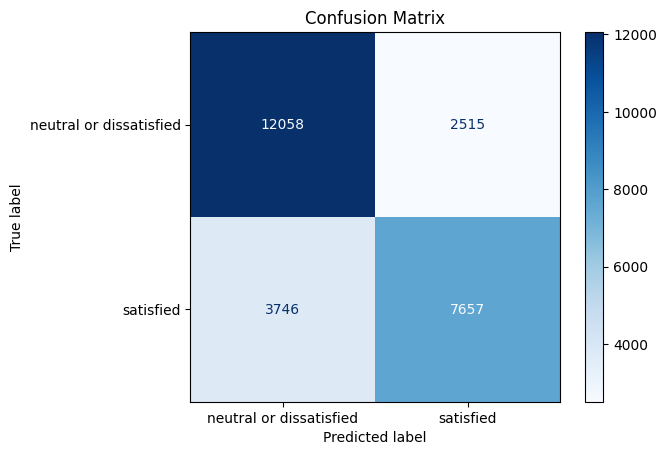

==================== NaiveBayes ====================



 confusion_matrix    [[13226, 1347], [2535, 8868]]
accuracy                                 0.850554
precision                                 0.85188
recall                                   0.850554
F1                                       0.849374
dtype: object 



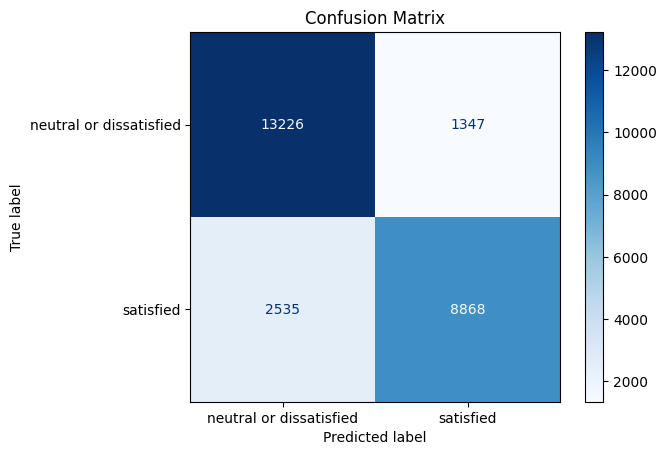

==================== SVM ====================



 confusion_matrix    [[12271, 2302], [6269, 5134]]
accuracy                                 0.670042
precision                                0.674403
recall                                   0.670042
F1                                       0.655066
dtype: object 



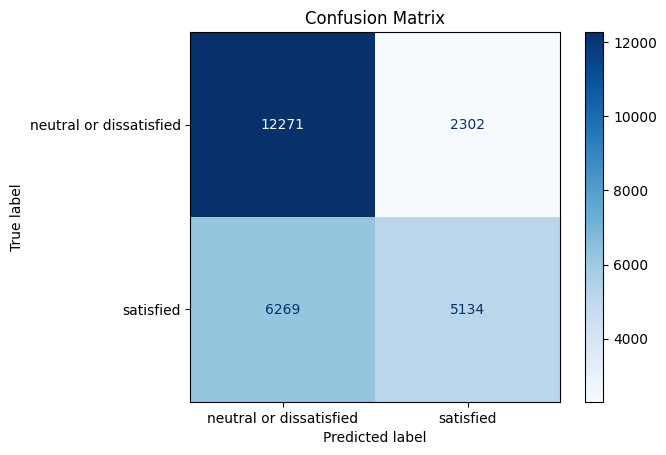

In [125]:

for modelName , y_predict in dict_predictions.items():
  print("="*50)
  print("="*20 , modelName, "="*20)
  print("="*50)
  print()
  print()

  dict_evaluation_info = Evaluate_classification_model(actual_values=y_test , predicted_values=y_predict)
  print("\n", pd.Series(dict_evaluation_info), "\n")

  # 5- Visualize confusion Matrix
  labels = ser_count.index.tolist()
  visualize_confusion_matrix(confusion_matrix=dict_evaluation_info["confusion_matrix"],
                            labels=labels)

#8- Final Result

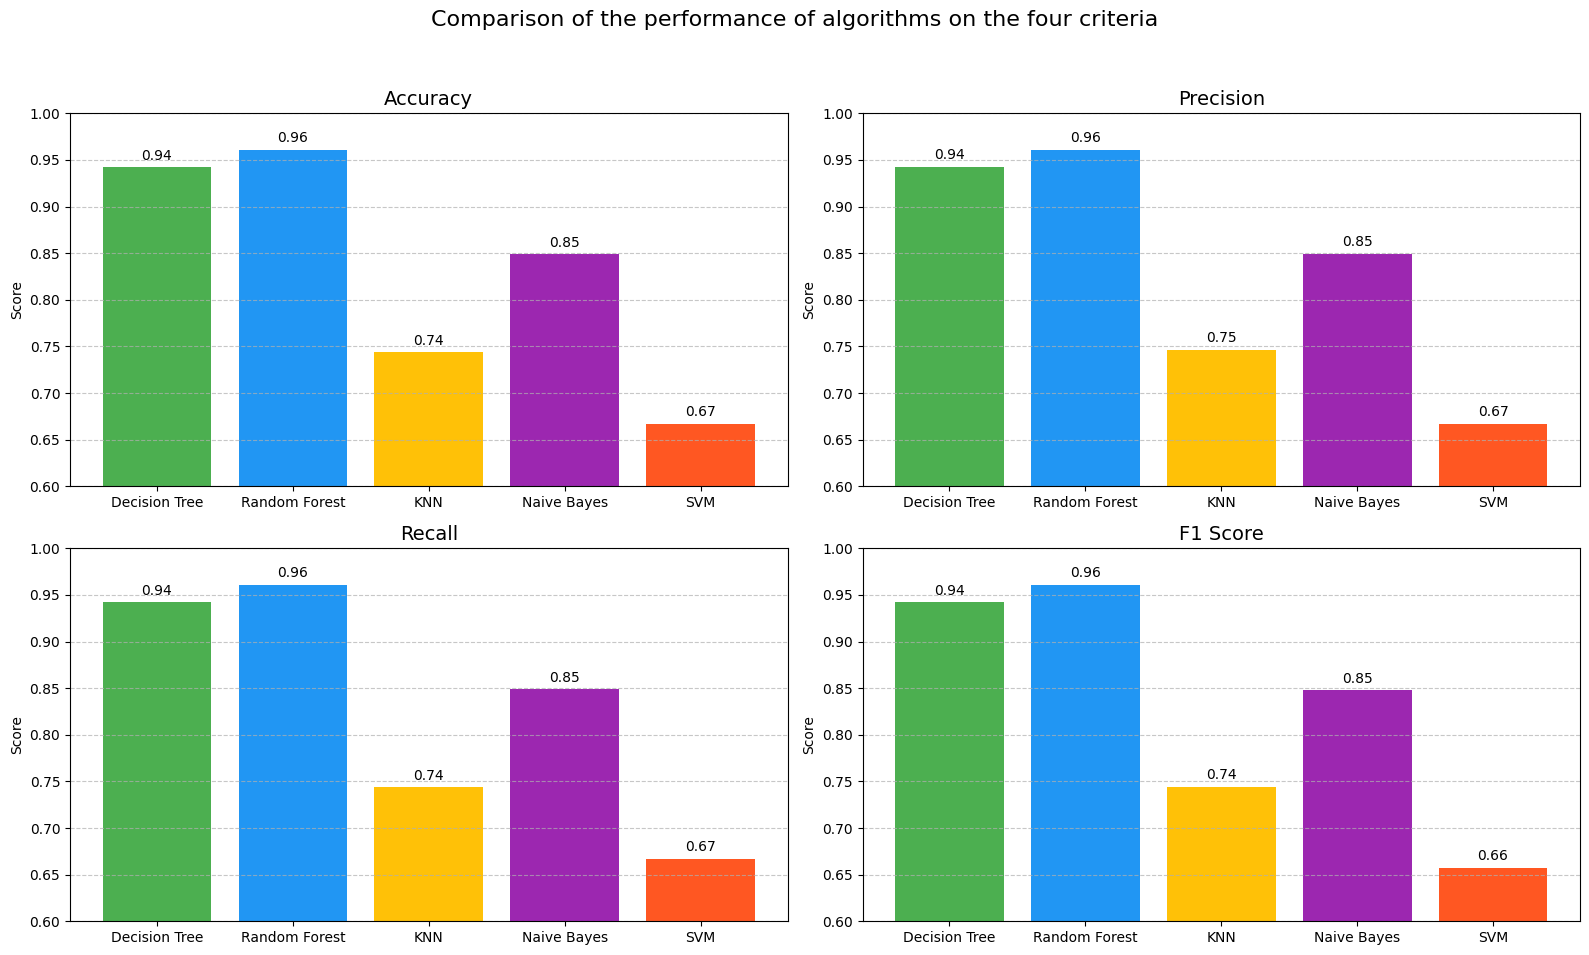

In [126]:

models = ['Decision Tree', 'Random Forest', 'KNN', 'Naive Bayes', 'SVM']

accuracy  = [0.9420, 0.9608, 0.7436, 0.8488, 0.6671]
precision = [0.9423, 0.9609, 0.7460, 0.8496, 0.6667]
recall    = [0.9420, 0.9608, 0.7436, 0.8488, 0.6671]
f1_score  = [0.9421, 0.9608, 0.7442, 0.8478, 0.6571]

metrics = {
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1 Score': f1_score
}

colors = ['#4CAF50', '#2196F3', '#FFC107', '#9C27B0', '#FF5722']

plt.figure(figsize=(16, 10))
for i, (metric_name, values) in enumerate(metrics.items(), 1):
    plt.subplot(2, 2, i)
    bars = plt.bar(models, values, color=colors)
    plt.ylim(0.6, 1.0)
    plt.title(metric_name, fontsize=14)
    plt.ylabel('Score')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f"{yval:.2f}", ha='center', va='bottom', fontsize=10)

plt.suptitle('Comparison of the performance of algorithms on the four criteria', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
